# RMSSD Signal Test

This notebook loads one example dyad with the dataloader, verifies that the RMSSD modality was computed, and plots caregiver IBI and RMSSD over the time span covering the three movie events with a 10-second margin before and after.

In [1]:
import os
import sys

import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
from src import dataloader

%matplotlib inline

In [2]:
data_base_path = '../data'
dyad_id = 'W_030'
margin_s = 10.0
decimate_factor = 8
window_size = 10.0  # seconds, used for RMSSD computation
plot_flag = False

if not os.path.isdir(data_base_path):
    raise FileNotFoundError(
        f'Example data directory not found: {data_base_path}. Adjust data_base_path to a valid raw-data folder.'
    )

In [3]:
multimodal_data = dataloader.create_multimodal_data(
    data_base_path=data_base_path,
    dyad_id=dyad_id,
    load_eeg=True,
    load_et=False,
    load_meta=False,
    window_size=window_size,
    decimate_factor=decimate_factor,
    plot_flag=plot_flag,
)

print('Loaded modalities:', multimodal_data.modalities)
required_rmssd_columns = ['RMSSD_ch', 'RMSSD_cg']
missing_rmssd_columns = [
    column for column in required_rmssd_columns if column not in multimodal_data.data.columns
]

if 'RMSSD' not in multimodal_data.modalities:
    raise AssertionError('RMSSD modality was not added to multimodal_data.modalities.')
if missing_rmssd_columns:
    raise AssertionError(f'Missing RMSSD columns: {missing_rmssd_columns}')
if multimodal_data.data['RMSSD_cg'].dropna().empty:
    raise AssertionError('RMSSD_cg was created but contains only NaN values.')

print(multimodal_data.data[['time', 'IBI_cg', 'RMSSD_cg']].dropna(how='all').head())

Detected events: {'Brave': {'name': 'Brave', 'start': 387.806640625, 'duration': 59.3310546875}, 'Peppa': {'name': 'Peppa', 'start': 248.5107421875, 'duration': 59.6328125}, 'Incredibles': {'name': 'Incredibles', 'start': 318.3603515625, 'duration': 59.212890625}, 'Talk_1': {'name': 'Talk_1', 'start': 594.4892578125, 'duration': 181.0556640625}, 'Talk_2': {'name': 'Talk_2', 'start': 836.7275390625, 'duration': 181.056640625}}
Applying fir filters to EEG data.
Reseting the EEG time to the start of Peppa
No ET_event found, using EEG_events data only.
Events column created based on EEG_events and ET_event columns.
Event structure created based on events column.

Event Name                     Start (s)       Duration (s)   
Peppa                          0.00            59.62          
Incredibles                    69.86           59.20          
Brave                          139.30          59.32          
Talk_1                         345.98          181.05         
Talk_2           

In [4]:
movie_names = ['Brave', 'Peppa', 'Incredibles']
missing_movies = [name for name in movie_names if name not in multimodal_data.events]
if missing_movies:
    raise KeyError(f'Missing movie events in multimodal_data.events: {missing_movies}')

movie_start = min(multimodal_data.events[name]['start'] for name in movie_names) - margin_s
movie_end = max(
    multimodal_data.events[name]['start'] + multimodal_data.events[name]['duration']
    for name in movie_names
) + margin_s

movie_window = multimodal_data.data.loc[
    (multimodal_data.data['time'] >= movie_start)
    & (multimodal_data.data['time'] <= movie_end)
].copy()

if movie_window.empty:
    raise ValueError('Selected movie window is empty.')

print(f'Plotting dyad {dyad_id} from {movie_start:.2f}s to {movie_end:.2f}s')
movie_window[['time', 'IBI_cg', 'RMSSD_cg']].head()

Plotting dyad W_030 from -10.00s to 208.62s


,time,IBI_cg,RMSSD_cg
30530,-9.995117,776.925882,88.965928
30531,-9.987305,776.625680,88.944539
30532,-9.979492,776.333815,88.983328
30533,-9.971680,776.050408,88.917721
30534,-9.963867,775.775584,89.023052


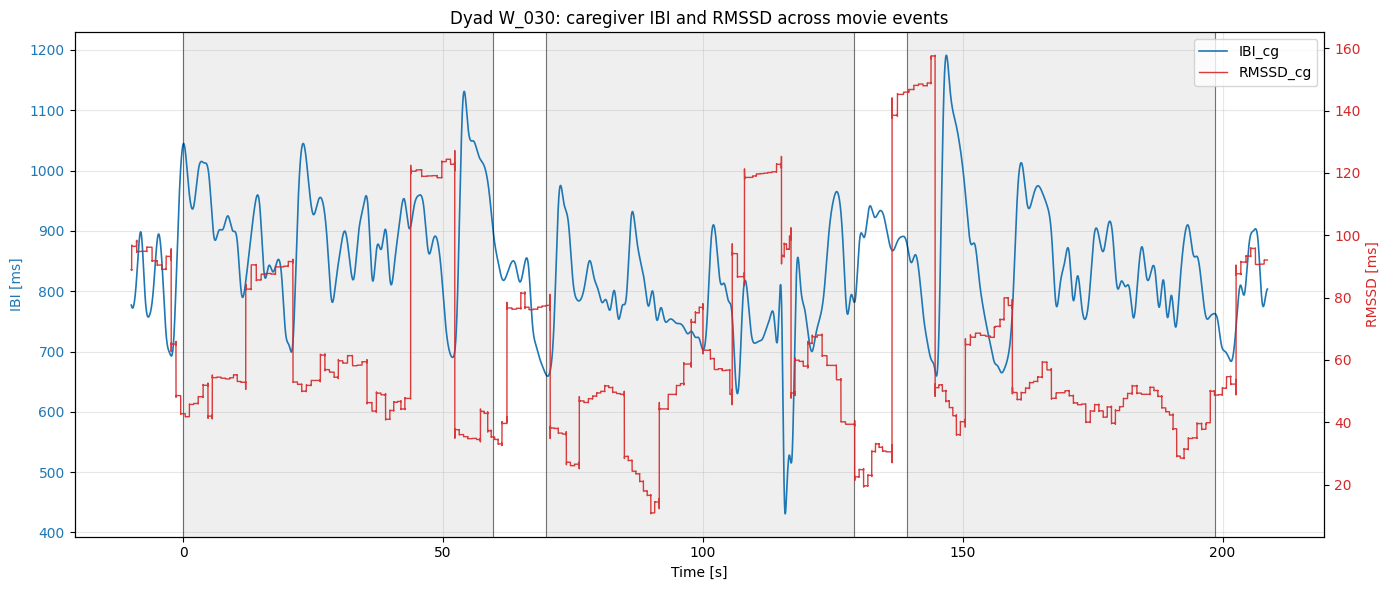

In [5]:
fig, ax_ibi = plt.subplots(figsize=(14, 6))
ax_ibi.plot(movie_window['time'], movie_window['IBI_cg'], color='tab:blue', linewidth=1.2, label='IBI_cg')
ax_ibi.set_xlabel('Time [s]')
ax_ibi.set_ylabel('IBI [ms]', color='tab:blue')
ax_ibi.tick_params(axis='y', labelcolor='tab:blue')
ax_ibi.grid(True, alpha=0.3)

ax_rmssd = ax_ibi.twinx()
ax_rmssd.plot(movie_window['time'], movie_window['RMSSD_cg'], color='tab:red', linewidth=1.0, alpha=0.9, label='RMSSD_cg')
ax_rmssd.set_ylabel('RMSSD [ms]', color='tab:red')
ax_rmssd.tick_params(axis='y', labelcolor='tab:red')

for movie_name in movie_names:
    event = multimodal_data.events[movie_name]
    event_start = event['start']
    event_end = event['start'] + event['duration']
    ax_ibi.axvspan(event_start, event_end, color='grey', alpha=0.12)
    ax_ibi.axvline(event_start, color='black', linewidth=0.8, alpha=0.5)
    ax_ibi.axvline(event_end, color='black', linewidth=0.8, alpha=0.5)

handles_ibi, labels_ibi = ax_ibi.get_legend_handles_labels()
handles_rmssd, labels_rmssd = ax_rmssd.get_legend_handles_labels()
ax_ibi.legend(handles_ibi + handles_rmssd, labels_ibi + labels_rmssd, loc='upper right')
plt.title(f'Dyad {dyad_id}: caregiver IBI and RMSSD across movie events')
plt.tight_layout()
plt.show()

## And the same for the child

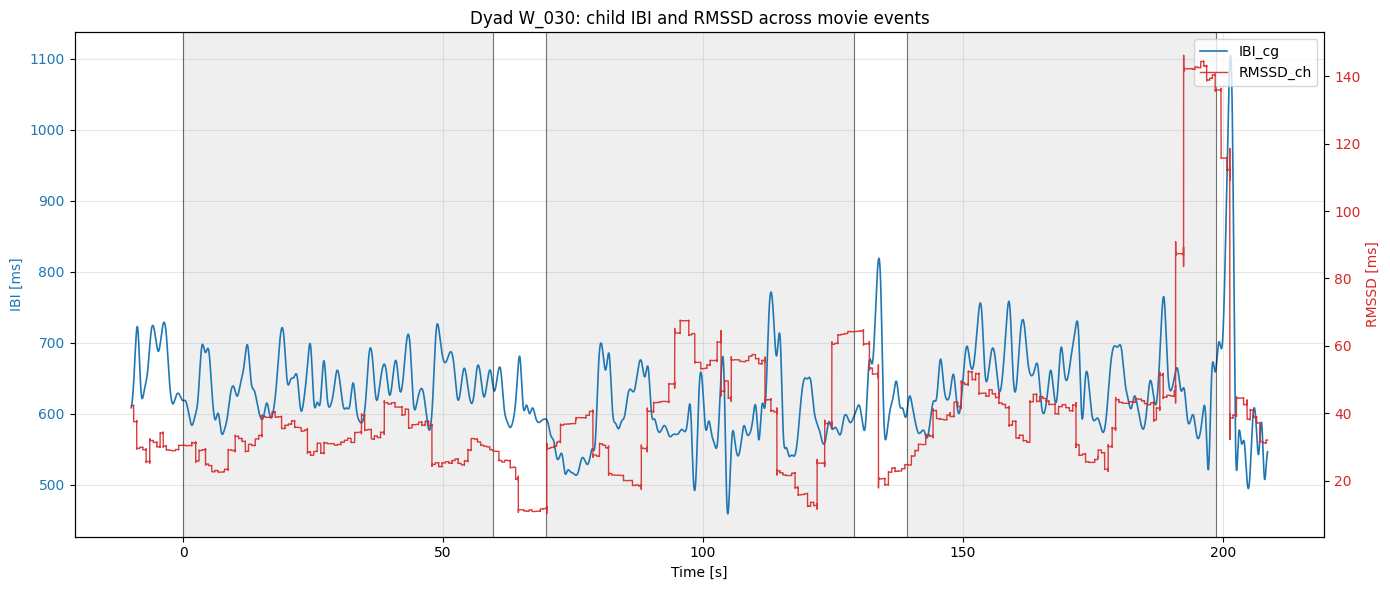

In [6]:
fig, ax_ibi = plt.subplots(figsize=(14, 6))
ax_ibi.plot(movie_window['time'], movie_window['IBI_ch'], color='tab:blue', linewidth=1.2, label='IBI_cg')
ax_ibi.set_xlabel('Time [s]')
ax_ibi.set_ylabel('IBI [ms]', color='tab:blue')
ax_ibi.tick_params(axis='y', labelcolor='tab:blue')
ax_ibi.grid(True, alpha=0.3)

ax_rmssd = ax_ibi.twinx()
ax_rmssd.plot(movie_window['time'], movie_window['RMSSD_ch'], color='tab:red', linewidth=1.0, alpha=0.9, label='RMSSD_ch')
ax_rmssd.set_ylabel('RMSSD [ms]', color='tab:red')
ax_rmssd.tick_params(axis='y', labelcolor='tab:red')

for movie_name in movie_names:
    event = multimodal_data.events[movie_name]
    event_start = event['start']
    event_end = event['start'] + event['duration']
    ax_ibi.axvspan(event_start, event_end, color='grey', alpha=0.12)
    ax_ibi.axvline(event_start, color='black', linewidth=0.8, alpha=0.5)
    ax_ibi.axvline(event_end, color='black', linewidth=0.8, alpha=0.5)

handles_ibi, labels_ibi = ax_ibi.get_legend_handles_labels()
handles_rmssd, labels_rmssd = ax_rmssd.get_legend_handles_labels()
ax_ibi.legend(handles_ibi + handles_rmssd, labels_ibi + labels_rmssd, loc='upper right')
plt.title(f'Dyad {dyad_id}: child IBI and RMSSD across movie events')
plt.tight_layout()
plt.show()